# Q1. Supervised Learning

Build and evaluate classification models to predict whether a patient has heart disease

**Target Variable:** `heart_disease`
(1 = disease present, 0 = absent)

In [25]:
# Task 1 - Data Loading and Inspection

import pandas as pd

# Load data
df = pd.read_csv("../data/q1_heart_disease.csv")

# Basic inspection
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())

df.head()

(800, 12)
age                  int64
sex                  int64
chest_pain_type        str
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg            str
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope               str
heart_disease        int64
dtype: object
age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64


,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0


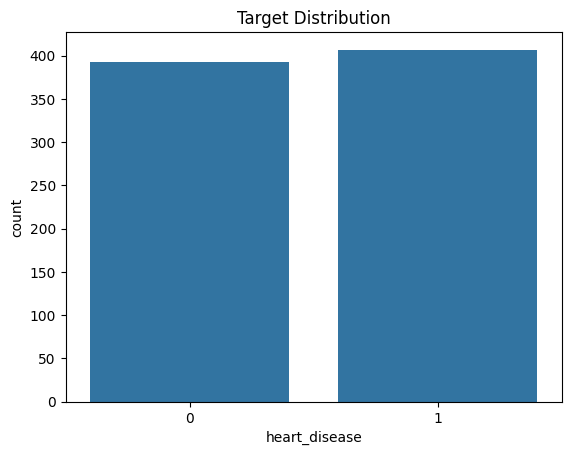

In [26]:
# Task 2 - Exploratory Data Analysis

import matplotlib.pyplot as plt
import seaborn as sns

# Target distribution
sns.countplot(x='heart_disease', data=df)
plt.title("Target Distribution")
plt.show()

### Insight: Target Distribution

The dataset appears to be fairly balanced, with a similar number of patients having heart disease and not having heart disease.

This is beneficial for model training as it reduces the risk of bias toward one class and improves the reliability of evaluation metrics.

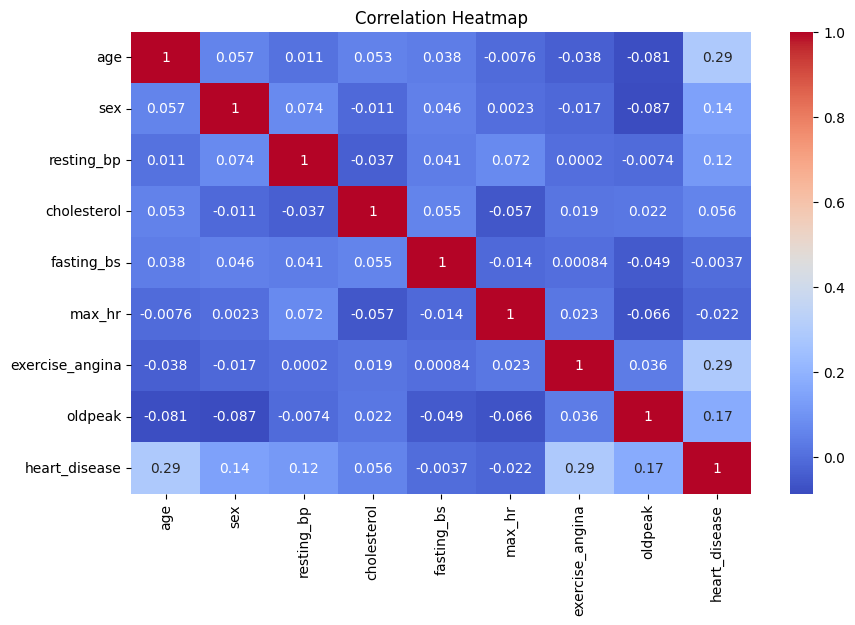

In [27]:
# Correlation heaatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

### Insight: Correaltion Heatmap

The correlation heatmap shows that most features have low to moderate correlation with the target variable.

The map also suggets that combining multiple features will be important for building an effective model.

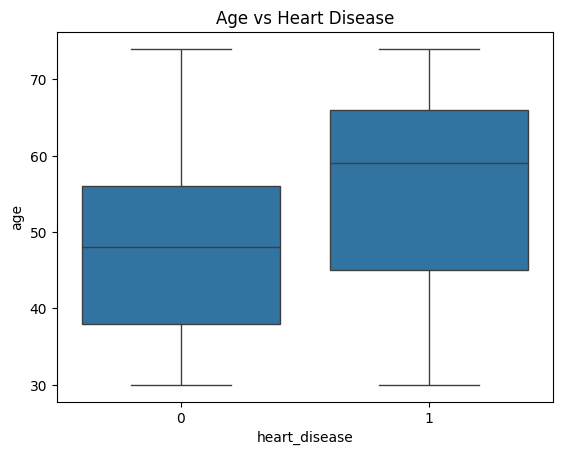

In [28]:
# Age vs Heart disease - Box plot
sns.boxplot(x='heart_disease', y='age', data=df)
plt.title("Age vs Heart Disease")
plt.show()

### Insight: Age vs Heart Disease

The boxplot shows that patients with heart disease tend to be older compared to those without heart disease.
-> The median age of heart disease patients is higher.
-> There is also wider spread of age values among affected patients
This indicate that age is an imprtant factor and may contribute significantly to predicting heart disease.

In [29]:
# Task 3 - Data preprocessing

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Handle missing values
df = df.fillna(df.median(numeric_only=True))

# One-hot encoding
df = pd.get_dummies(df, drop_first=True)

# Split
X = df.drop("heart_disease", axis=1)
y = df["heart_disease"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Missing Value Handling
Missing values are handled using **median imputation** for numerical features.

Approximatley 7% (56/800) of the data contains missing values. Dropping these rows would result in a noticeable loss of data. Therefore, median imputation is uses as it preserves the dataset size and is robust to outliers.

In [30]:
# Task 4 - Model Training

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

dt = DecisionTreeClassifier(random_state=42)
rf = RandomForestClassifier(random_state=42)
gb = GradientBoostingClassifier(random_state=42)

dt.fit(X_train, y_train)
rf.fit(X_train, y_train)
gb.fit(X_train, y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [31]:
# Task 5 - Model Evaluation

from sklearn.metrics import classification_report, confusion_matrix

models = {
    "Decision Tree": dt,
    "Random Forest": rf,
    "Gradient Boosting": gb
}

result = {}

for name, model in models.items():
    print(f"\n{name}")

    y_pred = model.predict(X_test)

    print("Confusion Matrix: ")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report: ")
    print(classification_report(y_test, y_pred))


Decision Tree
Confusion Matrix: 
[[57 22]
 [25 56]]

Classification Report: 
              precision    recall  f1-score   support

           0       0.70      0.72      0.71        79
           1       0.72      0.69      0.70        81

    accuracy                           0.71       160
   macro avg       0.71      0.71      0.71       160
weighted avg       0.71      0.71      0.71       160


Random Forest
Confusion Matrix: 
[[61 18]
 [15 66]]

Classification Report: 
              precision    recall  f1-score   support

           0       0.80      0.77      0.79        79
           1       0.79      0.81      0.80        81

    accuracy                           0.79       160
   macro avg       0.79      0.79      0.79       160
weighted avg       0.79      0.79      0.79       160


Gradient Boosting
Confusion Matrix: 
[[61 18]
 [19 62]]

Classification Report: 
              precision    recall  f1-score   support

           0       0.76      0.77      0.77        79

### Model comparison and Conclusion

Among the three models, **Random Forest** performs the best based on F1-score and balanced precision recall.

-> Decision Tree shows lower performance and is prone to overfitting
-> Gradient Boosting performs well but is slightly less effective than Random Forest
-> Random Forest provides the best balance between bias and variance.

Hence, Random Forest is selected as the best performing model for this dataset.

In [32]:
# Task 6 - Hyperparameter Tuning

from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="f1"
)

grid.fit(X_train, y_train)

print("Best parameters: ", grid.best_params_)

best_model = grid.best_estimator_

# Evaluate tuned model
y_pred = best_model.predict(X_test)

print("Confusion Matrix: ")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report: ")
print(classification_report(y_test, y_pred))

Best parameters:  {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}
Confusion Matrix: 
[[59 20]
 [16 65]]

Classification Report: 
              precision    recall  f1-score   support

           0       0.79      0.75      0.77        79
           1       0.76      0.80      0.78        81

    accuracy                           0.78       160
   macro avg       0.78      0.77      0.77       160
weighted avg       0.78      0.78      0.77       160

